# 07 -- World Bank Physical Coffee Prices: Arabica & Robusta Backtest

Validates the L1 price-position signal on World Bank Pink Sheet monthly prices:
- **WB Arabica** (Other Mild Arabicas, proxy for ICO Arabica indicator)
- **WB Robusta** (proxy for ICO Robusta indicator)

Also runs an Arabica basis analysis: how closely do WB physical prices track ICE KC=F futures?

**Gates (same thresholds as notebook 01):**

| Gate | Metric | Threshold |
|------|--------|-----------|
| 1 | Contemporaneous r(price_pos, trailing YoY) | >= +0.50 |
| 2 | BUY-weighted avg cost < naive avg | Any positive saving |
| 3 | BUY zone avg < naive avg < AVOID zone avg | Monotone |


## Sec 0  Setup


In [1]:
import os
import sys  # noqa: E401

sys.path.insert(0, os.path.abspath('../..'))

import warnings

warnings.filterwarnings('ignore')


In [2]:
from datetime import date  # noqa: E402

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import pandas as pd  # noqa: E402
from scipy import stats  # noqa: E402


In [3]:
from domains.coffee.features.price_features import (  # noqa: E402
    price_position_52w,
    yoy_price_change,
)
from domains.coffee.sources.world_bank_commodity import fetch  # noqa: E402


## Sec 1  Fetch World Bank Data


In [4]:
START = date(2000, 1, 1)
END   = date(2025, 12, 31)

obs, run = fetch(START, END)
print(f'Status : {run.status}')
print(f'Records: {run.records_fetched}')


Status : RunStatus.SUCCESS
Records: 624


In [5]:
arabica_obs = [o for o in obs if 'arabica' in o.asset_id]
robusta_obs = [o for o in obs if 'robusta' in o.asset_id]


def obs_to_df(observations, col='settle'):
    rows = [{'date': o.observed_date, col: o.value} for o in observations]
    df = pd.DataFrame(rows).set_index('date')
    df.index = pd.to_datetime(df.index)
    return df.sort_index()


wb_arabica = obs_to_df(arabica_obs)
wb_robusta = obs_to_df(robusta_obs)

print(f'Arabica: {len(wb_arabica)} months, '
      f'{wb_arabica.index[0].date()} to {wb_arabica.index[-1].date()}')
print(f'Robusta: {len(wb_robusta)} months, '
      f'{wb_robusta.index[0].date()} to {wb_robusta.index[-1].date()}')
jan24_ara = wb_arabica.loc['2024-01', 'settle'].values[0]
jan24_rob = wb_robusta.loc['2024-01', 'settle'].values[0]
print(f'Arabica Jan 2024: {jan24_ara:.2f} USc/lb')
print(f'Robusta Jan 2024: {jan24_rob:.2f} USc/lb')


Arabica: 312 months, 2000-01-31 to 2025-12-31
Robusta: 312 months, 2000-01-31 to 2025-12-31
Arabica Jan 2024: 202.90 USc/lb
Robusta Jan 2024: 148.05 USc/lb


## Sec 2  Load ICE KC=F Reference Data


In [6]:
kc_df = pd.read_csv('data/ice_kc_monthly.csv', parse_dates=['date'], index_col='date')
print(f'KC=F: {len(kc_df)} months, {kc_df.index[0].date()} to {kc_df.index[-1].date()}')
kc_df.head(3)


KC=F: 221 months, 2008-01-31 to 2026-05-31


,settle
date,
2008-01-31,138.149994
2008-02-29,164.600006
2008-03-31,127.400002


## Sec 3  Arabica Basis Analysis: WB Physical vs ICE KC=F Futures

A high correlation confirms WB can serve as an alternative L1 data source.


In [7]:
merged = kc_df[['settle']].rename(columns={'settle': 'kc_settle'}).join(
    wb_arabica.rename(columns={'settle': 'wb_arabica'}),
    how='inner',
)
core_m = merged.loc['2010-01-01':'2024-12-31'].dropna()

r_basis, p_basis = stats.pearsonr(core_m['kc_settle'], core_m['wb_arabica'])
print(f'Correlation KC=F vs WB Arabica (2010-2024): r = {r_basis:.4f}, p = {p_basis:.4e}')

core_m = core_m.copy()
core_m['basis'] = core_m['wb_arabica'] - core_m['kc_settle']
print(f'Mean basis (WB - KC=F): {core_m["basis"].mean():.2f} USc/lb')
print(f'Std  basis            : {core_m["basis"].std():.2f} USc/lb')


Correlation KC=F vs WB Arabica (2010-2024): r = 0.9693, p = 2.0631e-110
Mean basis (WB - KC=F): 25.18 USc/lb
Std  basis            : 12.43 USc/lb


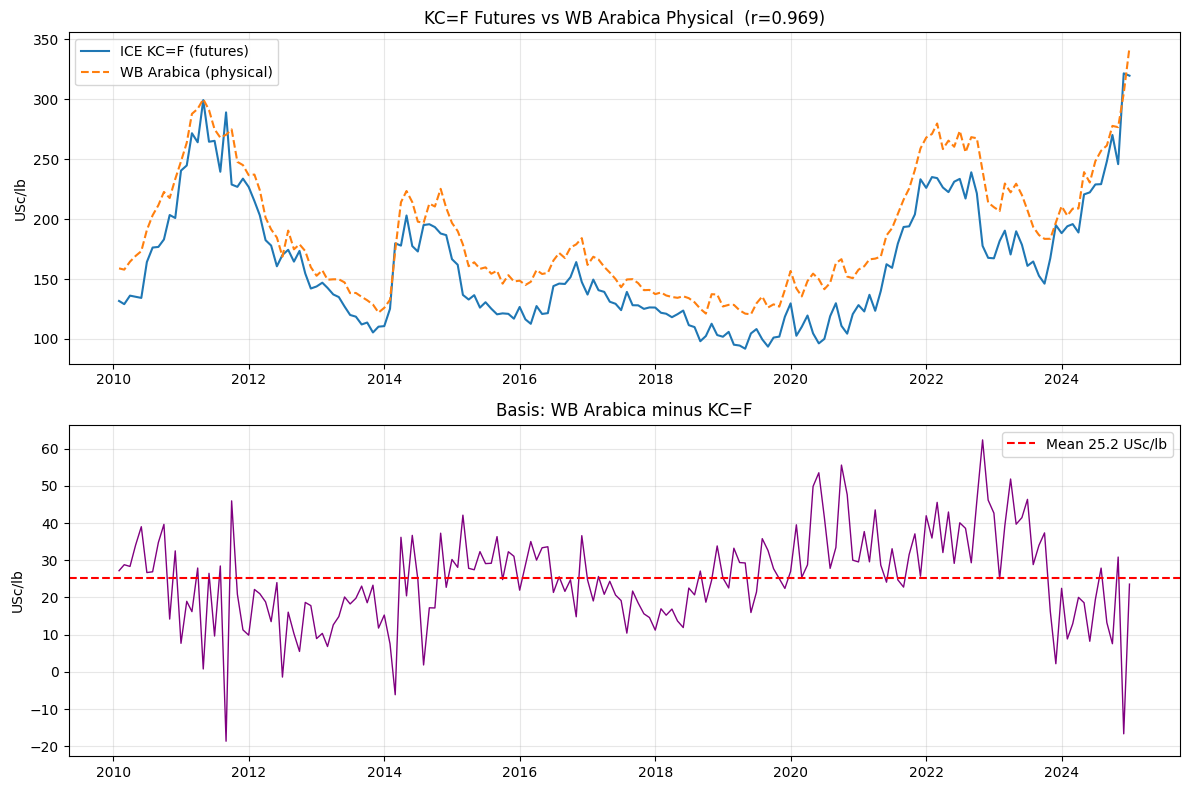

Saved: data/07_arabica_basis.png


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(core_m.index, core_m['kc_settle'],
             label='ICE KC=F (futures)', lw=1.5)
axes[0].plot(core_m.index, core_m['wb_arabica'],
             label='WB Arabica (physical)', lw=1.5, linestyle='--')
axes[0].set_title(f'KC=F Futures vs WB Arabica Physical  (r={r_basis:.3f})')
axes[0].set_ylabel('USc/lb')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(core_m.index, core_m['basis'], color='purple', lw=1)
mean_basis = core_m['basis'].mean()
axes[1].axhline(mean_basis, color='red', linestyle='--',
                label=f'Mean {mean_basis:.1f} USc/lb')
axes[1].set_title('Basis: WB Arabica minus KC=F')
axes[1].set_ylabel('USc/lb')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs('data', exist_ok=True)
plt.savefig('data/07_arabica_basis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/07_arabica_basis.png')


## Sec 4  Feature Engineering: price_position_52w on WB Data


In [9]:
def build_features(price_df, col='settle'):
    """Add price_position_52w and trailing_yoy to a monthly price DataFrame."""
    df = price_df.copy()
    series = df[col]  # pd.Series with DatetimeIndex
    df['price_pos']    = price_position_52w(series)
    df['trailing_yoy'] = yoy_price_change(series)
    df['buy_signal']   = (df['price_pos'] < 0.30).astype(float)
    return df


wb_arabica_f = build_features(wb_arabica)
wb_robusta_f = build_features(wb_robusta)

print('Arabica features (last 6 months):')
print(wb_arabica_f[['settle', 'price_pos', 'buy_signal']].tail(6).to_string())
print()
print('Robusta features (last 6 months):')
print(wb_robusta_f[['settle', 'price_pos', 'buy_signal']].tail(6).to_string())


Arabica features (last 6 months):
            settle  price_pos  buy_signal
date                                     
2025-07-31  325.50   0.429846         0.0
2025-08-31  366.32   0.669783         0.0
2025-09-30  400.59   0.926103         0.0
2025-10-31  403.79   0.936676         0.0
2025-11-30  410.31   0.998117         0.0
2025-12-31  381.23   0.655879         0.0

Robusta features (last 6 months):
            settle  price_pos  buy_signal
date                                     
2025-07-31  167.19   0.000000         1.0
2025-08-31  199.13   0.331122         0.0
2025-09-30  211.26   0.456873         0.0
2025-10-31  215.06   0.496268         0.0
2025-11-30  214.91   0.494713         0.0
2025-12-31  190.57   0.242380         1.0


## Sec 5  WB Arabica L1 Gates

Same three gates as notebook 01 (ICE KC=F).


In [10]:
def run_gates(df, label):
    """Run three L1 gates on a features DataFrame."""
    core = df.loc['2010-01-01':'2024-12-31'].dropna(
        subset=['buy_signal', 'settle', 'trailing_yoy', 'price_pos']
    )
    r_c, p_c = stats.pearsonr(core['price_pos'], core['trailing_yoy'])
    has_buys = core['buy_signal'].sum() > 0
    sig_avg   = np.average(core['settle'], weights=core['buy_signal']) if has_buys else np.nan
    naive_avg = core['settle'].mean()
    saving = (naive_avg - sig_avg) / naive_avg * 100 if has_buys else np.nan
    buy_z  = core.loc[core['price_pos'] < 0.30, 'settle']
    avoid_z = core.loc[core['price_pos'] > 0.70, 'settle']
    zone_mono = (
        bool(buy_z.mean() < naive_avg < avoid_z.mean())
        if len(buy_z) > 0 and len(avoid_z) > 0 else False
    )
    return {
        'label': label, 'n': len(core),
        'r': r_c, 'p': p_c,
        'saving': saving,
        'naive': naive_avg, 'sig': sig_avg,
        'buy_z': buy_z.mean() if len(buy_z) > 0 else np.nan,
        'avoid_z': avoid_z.mean() if len(avoid_z) > 0 else np.nan,
        'g1': r_c >= 0.50,
        'g2': bool(saving > 0) if not np.isnan(saving) else False,
        'g3': zone_mono,
    }


def print_gates(res):
    g1 = 'PASS' if res['g1'] else 'FAIL'
    g2 = 'PASS' if res['g2'] else 'FAIL'
    g3 = 'PASS' if res['g3'] else 'FAIL'
    ga = 'ALL GATES PASS' if (res['g1'] and res['g2'] and res['g3']) else 'GATE FAILURE'
    print(f"=== {res['label']} L1 Gates  (n={res['n']}) ===")
    print(f"Gate 1 -- r = {res['r']:+.4f}  p={res['p']:.2e}  {g1}")
    print(f"Gate 2 -- saving = {res['saving']:+.2f}%  "
          f"(naive={res['naive']:.1f}, sig={res['sig']:.1f})  {g2}")
    print(f"Gate 3 -- BUY={res['buy_z']:.1f} < "
          f"naive={res['naive']:.1f} < AVOID={res['avoid_z']:.1f}  {g3}")
    print(f"\n{ga}\n")


arabica_r = run_gates(wb_arabica_f, 'WB Arabica')
print_gates(arabica_r)


=== WB Arabica L1 Gates  (n=180) ===
Gate 1 -- r = +0.8347  p=5.57e-48  PASS
Gate 2 -- saving = +12.08%  (naive=186.9, sig=164.3)  PASS
Gate 3 -- BUY=164.3 < naive=186.9 < AVOID=213.8  PASS

ALL GATES PASS



## Sec 6  WB Robusta L1 Gates

First backtest of the L1 signal on Robusta prices.
Robusta dynamics differ from Arabica (lower vol, Vietnam supply driven).
Same gate thresholds maintained for consistency.


In [11]:
robusta_r = run_gates(wb_robusta_f, 'WB Robusta')
print_gates(robusta_r)


=== WB Robusta L1 Gates  (n=180) ===
Gate 1 -- r = +0.7477  p=1.77e-33  PASS
Gate 2 -- saving = +15.12%  (naive=100.2, sig=85.0)  PASS
Gate 3 -- BUY=85.0 < naive=100.2 < AVOID=115.4  PASS

ALL GATES PASS



## Sec 7  Walk-Forward Tests (no look-ahead)

Year-by-year cost saving using only data available at the start of each year.


In [12]:
def walk_forward(df, label, start_year=2013, end_year=2024):
    """Year-by-year walk-forward cost saving test."""
    results = []
    for yr in range(start_year, end_year + 1):
        train = df.loc[:f'{yr - 1}-12-31']
        if len(train) < 12:   # need at least 1 year of history
            continue
        yr_data = df.loc[f'{yr}-01-01':f'{yr}-12-31'].dropna(
            subset=['buy_signal', 'settle']
        )
        if len(yr_data) == 0:
            continue
        has_buys = yr_data['buy_signal'].sum() > 0
        if has_buys:
            sig_avg = np.average(yr_data['settle'], weights=yr_data['buy_signal'])
        else:
            sig_avg = yr_data['settle'].mean()
        naive_avg = yr_data['settle'].mean()
        yr_saving = (naive_avg - sig_avg) / naive_avg * 100
        results.append({'year': yr, 'saving_pct': yr_saving, 'n': len(yr_data)})

    wf = pd.DataFrame(results)
    avg_s  = wf['saving_pct'].mean()
    pos_yr = (wf['saving_pct'] > 0).sum()
    print(f'=== {label} Walk-Forward ({start_year}-{end_year}) ===')
    for _, row in wf.iterrows():
        print(f"  {int(row['year'])}: {row['saving_pct']:+.2f}%  (n={int(row['n'])})")
    print(f'\nAverage saving : {avg_s:+.2f}%')
    print(f'Positive years : {pos_yr}/{len(wf)}')
    return wf, avg_s


wf_arabica, avg_arabica = walk_forward(wb_arabica_f, 'WB Arabica')
print()
wf_robusta, avg_robusta = walk_forward(wb_robusta_f, 'WB Robusta')


=== WB Arabica Walk-Forward (2013-2024) ===
  2013: +0.00%  (n=12)
  2014: +0.00%  (n=12)
  2015: +1.71%  (n=12)
  2016: +10.64%  (n=12)
  2017: +2.22%  (n=12)
  2018: +0.28%  (n=12)
  2019: +6.71%  (n=12)
  2020: +0.00%  (n=12)
  2021: +0.00%  (n=12)
  2022: +13.34%  (n=12)
  2023: +2.82%  (n=12)
  2024: +0.00%  (n=12)

Average saving : +3.14%
Positive years : 7/12

=== WB Robusta Walk-Forward (2013-2024) ===
  2013: +3.08%  (n=12)
  2014: +0.00%  (n=12)
  2015: +0.00%  (n=12)
  2016: +15.59%  (n=12)
  2017: +6.76%  (n=12)
  2018: -0.09%  (n=12)
  2019: -0.08%  (n=12)
  2020: +3.24%  (n=12)
  2021: +0.00%  (n=12)
  2022: +6.24%  (n=12)
  2023: +19.45%  (n=12)
  2024: +0.00%  (n=12)

Average saving : +4.52%
Positive years : 6/12


## Sec 8  Save Reference CSVs


In [13]:
os.makedirs('data', exist_ok=True)
wb_arabica_f.to_csv('data/wb_arabica_monthly.csv')
wb_robusta_f.to_csv('data/wb_robusta_monthly.csv')
print('Saved: data/wb_arabica_monthly.csv')
print('Saved: data/wb_robusta_monthly.csv')


Saved: data/wb_arabica_monthly.csv
Saved: data/wb_robusta_monthly.csv


## Sec 9  Summary


In [14]:
print('=' * 60)
print('World Bank Physical Coffee Prices -- Backtest Summary')
print('=' * 60)
print()
print('Arabica (Other Mild Arabicas -- proxy ICO Arabica indicator)')
a_g1 = 'PASS' if arabica_r['g1'] else 'FAIL'
a_g2 = 'PASS' if arabica_r['g2'] else 'FAIL'
a_g3 = 'PASS' if arabica_r['g3'] else 'FAIL'
print(f"  Gate 1 r      : {arabica_r['r']:+.4f}  {a_g1}")
print(f"  Gate 2 saving : {arabica_r['saving']:+.2f}%  {a_g2}")
print(f"  Gate 3 zone   : {a_g3}")
print(f'  Walk-forward  : {avg_arabica:+.2f}% avg')
print()
print('Robusta (Vietnam/Uganda -- proxy ICO Robusta indicator)')
r_g1 = 'PASS' if robusta_r['g1'] else 'FAIL'
r_g2 = 'PASS' if robusta_r['g2'] else 'FAIL'
r_g3 = 'PASS' if robusta_r['g3'] else 'FAIL'
print(f"  Gate 1 r      : {robusta_r['r']:+.4f}  {r_g1}")
print(f"  Gate 2 saving : {robusta_r['saving']:+.2f}%  {r_g2}")
print(f"  Gate 3 zone   : {r_g3}")
print(f'  Walk-forward  : {avg_robusta:+.2f}% avg')
print()
print(f'Arabica Basis (WB vs KC=F, 2010-2024): r = {r_basis:.4f}')
print()
all_a = arabica_r['g1'] and arabica_r['g2'] and arabica_r['g3']
all_r = robusta_r['g1'] and robusta_r['g2'] and robusta_r['g3']
v_a = 'ALL GATES PASS' if all_a else 'GATE FAILURE'
v_r = 'ALL GATES PASS' if all_r else 'GATE FAILURE'
print(f'Arabica verdict : {v_a}')
print(f'Robusta verdict : {v_r}')


World Bank Physical Coffee Prices -- Backtest Summary

Arabica (Other Mild Arabicas -- proxy ICO Arabica indicator)
  Gate 1 r      : +0.8347  PASS
  Gate 2 saving : +12.08%  PASS
  Gate 3 zone   : PASS
  Walk-forward  : +3.14% avg

Robusta (Vietnam/Uganda -- proxy ICO Robusta indicator)
  Gate 1 r      : +0.7477  PASS
  Gate 2 saving : +15.12%  PASS
  Gate 3 zone   : PASS
  Walk-forward  : +4.52% avg

Arabica Basis (WB vs KC=F, 2010-2024): r = 0.9693

Arabica verdict : ALL GATES PASS
Robusta verdict : ALL GATES PASS
